# Finetuneando un modelo de difusión

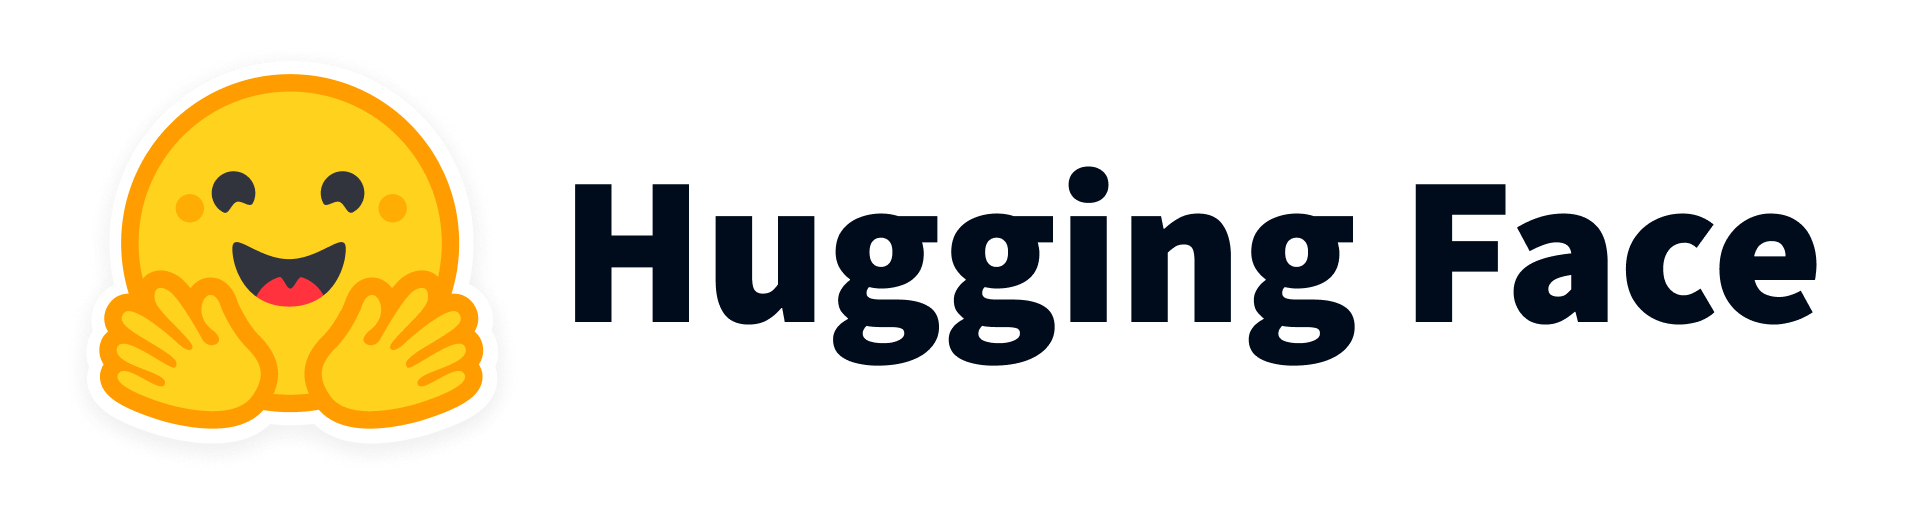

version 1.0

# 0. Instalacion de librerias

In [1]:
!pip install -qq diffusers "datasets>=2.16,<2.17" accelerate

In [2]:
# Importamos las librerias necesarias:
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
from datasets import load_dataset
from diffusers import DDIMScheduler, DDPMPipeline
from matplotlib import pyplot as plt
from PIL import Image
from torchvision import transforms
from tqdm.auto import tqdm

In [3]:
# Vamos a utilizar GPU, necesaria para el entrenamiento:

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


# 1. Cargamos un modelo de difusión pre-entrenado

In [4]:

# Cargamos un modelo de difusión pre-entrenado:
model_id = "google/ddpm-celebahq-256"
image_pipe = DDPMPipeline.from_pretrained(model_id)

image_pipe.to(device)



Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/alexd/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory /home/alexd/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


DDPMPipeline {
  "_class_name": "DDPMPipeline",
  "_diffusers_version": "0.38.0",
  "_name_or_path": "google/ddpm-celebahq-256",
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

In [5]:
from diffusers import DDPMScheduler

image_pipe.scheduler = DDPMScheduler.from_config(
    image_pipe.scheduler.config,
    num_train_timesteps=1000,   # original
    num_inference_steps=50      # lo que tú quieres
)


  0%|          | 0/1000 [00:00<?, ?it/s]

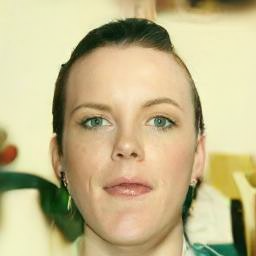

In [6]:
image_pipe().images[0]

Como vemos, el scheduler que viene con este modelo pre-entrenado tiene 1.000 timesteps. Esto es muy positivo para la fase de entrenamiento, ya que implica que el proceso de difusión va a ser añadiendo ruido muy lentamente en muchos timesteps, y por tanto el modelo aprenderá a quitar ruido con mayor precisión ya que tiene más granularidad en los timesteps.

Sin embargo, para el proceso de difusión hacia atrás (inferencia), puede ser muy pesado tener que esperar 1.000 pasos para cada imagen generada.

Por ello, podemos definir un nuevo scheduler con un número diferente de timesteps. Al hacerlo, la librería `diffusers` por dentro selecciona el nuevo número de timesteps de los 1.000 originales de manera lineal o exponencial, y actualiza automáticamente los valores de beta, alpha, sigma...etc.

El trade-off es: velocidad VS calidad de la generación.

In [7]:

# Definimos el nuevo scheduler con menos timesteps:
NUM_TIMESTEPS = 40
scheduler = DDIMScheduler.from_pretrained("google/ddpm-celebahq-256")
scheduler.set_timesteps(num_inference_steps=NUM_TIMESTEPS)

scheduler.timesteps


/home/alexd/modelo_gi/env-diffusers/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


tensor([975, 950, 925, 900, 875, 850, 825, 800, 775, 750, 725, 700, 675, 650,
        625, 600, 575, 550, 525, 500, 475, 450, 425, 400, 375, 350, 325, 300,
        275, 250, 225, 200, 175, 150, 125, 100,  75,  50,  25,   0])

Vamos a generar algunos ejemplos con el nuevo scheduler:

0it [00:00, ?it/s]

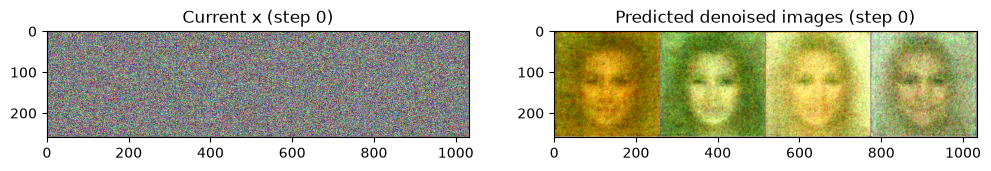

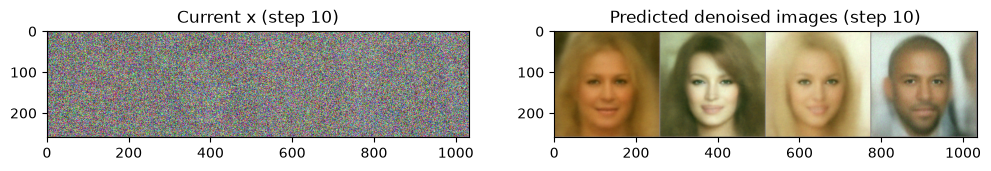

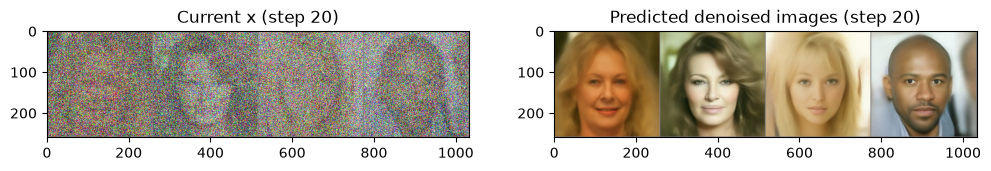

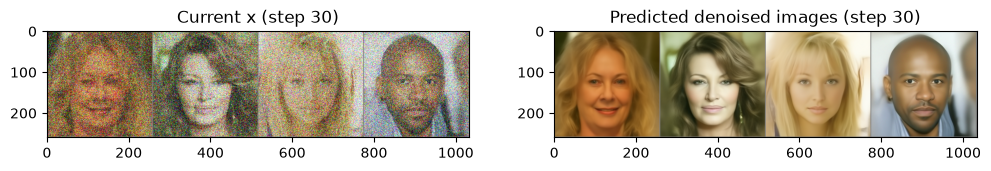

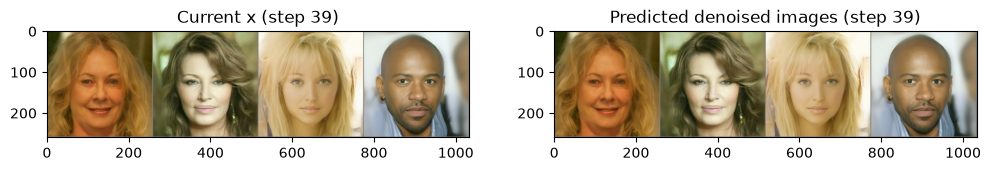

In [8]:
# Generamos 4 muestras de ruido aleatorio:
x = torch.randn(4, 3, 256, 256).to(device)  # batch de 4 imagenes (ruido), 3 canales y 256 x 256

# Iteramos sobre los timesteps:
for i, t in tqdm(enumerate(scheduler.timesteps)):

    # Preparamos el input al modelo:
    model_input = scheduler.scale_model_input(x, t)

    # Obtenemos el ruido predicho por el modelo:
    with torch.no_grad():
        noise_pred = image_pipe.unet(model_input, t)["sample"]

    # Con el ruido predicho, calculamos cual es la nueva imagen con menos ruido del siguiente paso:
    scheduler_output = scheduler.step(noise_pred, t, x)
    x = scheduler_output.prev_sample  # queremos x(t-1)

    # Cada 10 pasos mostrar el proceso de difusion:
    if i % 10 == 0 or i == len(scheduler.timesteps) - 1:
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))

        grid = torchvision.utils.make_grid(x, nrow=4).permute(1, 2, 0)
        axs[0].imshow(grid.cpu().clip(-1, 1) * 0.5 + 0.5)
        axs[0].set_title(f"Current x (step {i})")

        pred_x0 = scheduler_output.pred_original_sample
        grid = torchvision.utils.make_grid(pred_x0, nrow=4).permute(1, 2, 0)
        axs[1].imshow(grid.cpu().clip(-1, 1) * 0.5 + 0.5)
        axs[1].set_title(f"Predicted denoised images (step {i})")
        plt.show()

  0%|          | 0/40 [00:00<?, ?it/s]

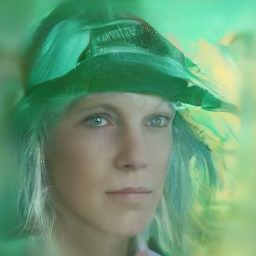

In [9]:
# Generamos otra muestra con el nuevo scheduler:
image_pipe.scheduler = scheduler
images = image_pipe(num_inference_steps=40).images

images[0]

# 2. Proceso de finetuning

In [10]:
# Cargamos un dataset de imagenes de Hugging Face:
dataset_name = "huggan/pokemon"
dataset = load_dataset(dataset_name, split="train")

number_samples = 50

# Hacemos un subsample del dataset para que quepa en memoria:
dataset = dataset.shuffle(seed=0).select(range(number_samples))
dataset

Repo card metadata block was not found. Setting CardData to empty.


Dataset({
    features: ['image'],
    num_rows: 50
})

In [11]:
# Transformamos las imagenes del dataset:
image_size = 256
batch_size = 4  # no puede ser mayor porque no nos cabe en la GPU de Collab:
preprocess = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}

dataset.set_transform(transform)

Visualizando un batch:


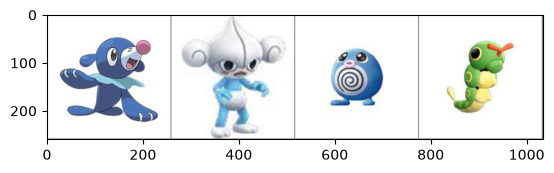

In [12]:
# Visualizamos algunas muestras del dataset:
train_dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

print("Visualizando un batch:")
batch = next(iter(train_dataloader))
grid = torchvision.utils.make_grid(batch["images"], nrow=4)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(-1, 1) * 0.5 + 0.5)

In [ ]:
# Preparamos el finetuning:
num_epochs = 3
lr = 1e-5
grad_accumulation_steps = 2  # para actualizar conforme al batch size

optimizer = torch.optim.AdamW(image_pipe.unet.parameters(), lr=lr)

losses = []

for epoch in range(num_epochs):
    for step, batch in tqdm(enumerate(train_dataloader), total=len(train_dataloader)):
        clean_images = batch["images"].to(device)

        # Creamos ruido aleatorio:
        noise = torch.randn(clean_images.shape).to(clean_images.device)
        bs = clean_images.shape[0]

        # Elegimos un timestep aleatorio:
        timesteps = torch.randint(
            0,
            image_pipe.scheduler.config.num_train_timesteps,
            (bs,),
            device=clean_images.device,
        ).long()

        # Proceso de difusion hacia delante:
        # Añadimos el ruido a la imagen limpia en funcion del timestep:
        noisy_images = image_pipe.scheduler.add_noise(clean_images, noise, timesteps)

        # Hacemos la prediccion del modelo:
        noise_pred = image_pipe.unet(noisy_images, timesteps, return_dict=False)[0]

        # Calculamos el error con la funcion de coste:
        loss = F.mse_loss(
            noise_pred, noise
        )

        # Guardamos el error solo para poder visualizarlo luego
        losses.append(loss.item())

        # Actualizamos los parametros del modelo:
        loss.backward(loss)

        # Gradient accumulation:
        if (step + 1) % grad_accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

    print(f"Epoch {epoch} average loss: {sum(losses[-len(train_dataloader):])/len(train_dataloader)}")

plt.plot(losses)

  0%|          | 0/13 [00:00<?, ?it/s]

# 3. Generación de nuevas imágenes con el modelo finetuneado

In [ ]:
# Generamos algunas imagenes con el nuevo modelo finetuneado:

x = torch.randn(8, 3, 256, 256).to(device)  # batch de 8 imagenes:
for i, t in tqdm(enumerate(scheduler.timesteps)):
    model_input = scheduler.scale_model_input(x, t)
    with torch.no_grad():
        noise_pred = image_pipe.unet(model_input, t)["sample"]
    x = scheduler.step(noise_pred, t, x).prev_sample
grid = torchvision.utils.make_grid(x, nrow=4)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(-1, 1) * 0.5 + 0.5)